# Import Libraries and Define Transformations
Import necessary libraries like `torch`, `torchvision`, `DataLoader`. Define image transformations using `transforms.Compose`, including resizing and converting to tensors.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image

# Set the device to MPS if available, otherwise fallback to CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {device}")

# Define transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images to 128x128
    transforms.ToTensor()
])

Using device: mps


# Load and Inspect Dataset
Load the image dataset using `datasets.ImageFolder`. Create a `DataLoader` for batching and shuffling. Print dataset details like number of classes, class names, and total number of samples.

In [2]:
# Load dataset
# Ensure the path is correct for your system
dataset_path = '/Users/ayush/Desktop/project_ayush_raj/data/test'
try:
    train_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    # Inspect dataset
    print(f"Number of classes: {len(train_dataset.classes)}")
    print(f"Class names: {train_dataset.classes}")
    print(f"Number of samples: {len(train_dataset)}")
    # Store class names for later use
    class_names = train_dataset.classes
except FileNotFoundError:
    print(f"Error: Dataset not found at path: {dataset_path}")
    print("Please ensure the dataset path is correct.")
    # Handle the error appropriately, e.g., exit or prompt user
    train_loader = None # Set to None to prevent errors in subsequent cells
    class_names = []
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")
    train_loader = None
    class_names = []


Number of classes: 7
Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of samples: 7178


# Visualize Data Samples
Import `matplotlib.pyplot`. Get a batch of images and labels from the `DataLoader`. Plot a few sample images along with their corresponding labels.

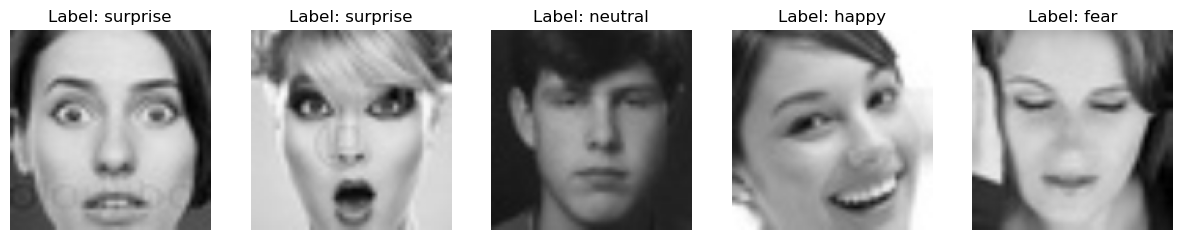

In [3]:
if train_loader:
    # Get a batch of images
    try:
        data_iter = iter(train_loader)
        images, labels = next(data_iter)

        # Plot images
        fig, axes = plt.subplots(1, 5, figsize=(15, 5))
        for i in range(min(5, len(images))): # Ensure we don't exceed batch size
            ax = axes[i]
            img = images[i].permute(1, 2, 0).squeeze() # Adjust for potential single-channel images
            cmap = 'gray' if img.ndim == 2 else None # Use grayscale cmap if image is 2D
            ax.imshow(img.numpy(), cmap=cmap) # Convert to numpy for imshow
            ax.set_title(f"Label: {class_names[labels[i]]}")
            ax.axis('off')
        plt.show()
    except StopIteration:
        print("DataLoader is empty.")
    except Exception as e:
        print(f"An error occurred during visualization: {e}")
else:
    print("Skipping data visualization as DataLoader could not be initialized.")

# Visualize Class Distribution
Import `seaborn` and `pandas`. Calculate the count of samples for each class in the training dataset. Plot the class distribution using a bar plot.

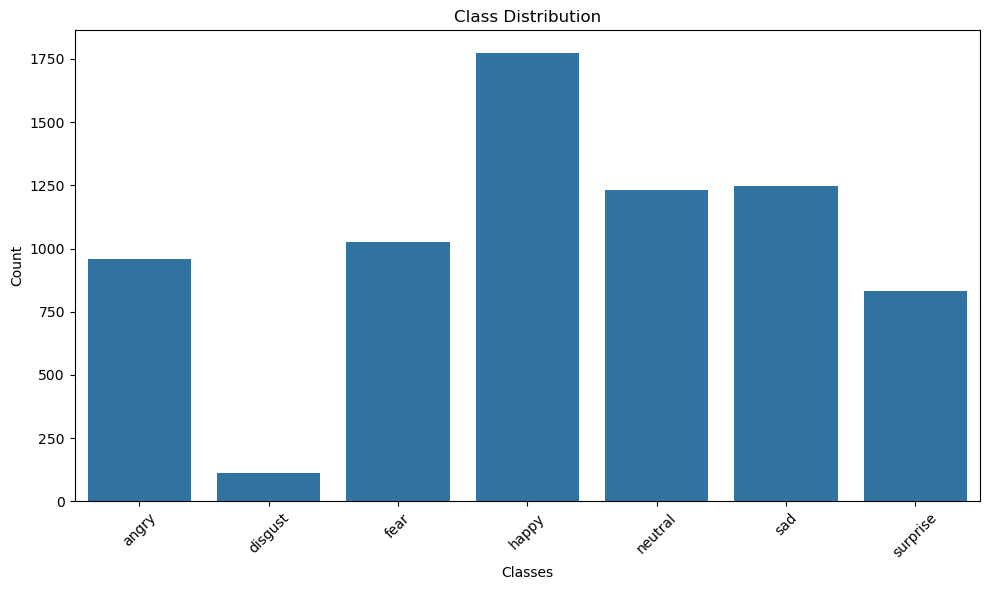

In [4]:
if train_loader:
    # Get class counts
    try:
        class_counts = [0] * len(class_names)
        # Accessing dataset directly might be inefficient for large datasets
        # If the dataset is large, consider iterating through the loader once
        # or using dataset.targets if available and applicable
        targets = []
        if hasattr(train_dataset, 'targets'):
             targets = train_dataset.targets
        elif hasattr(train_dataset, 'labels'): # Some datasets use 'labels'
             targets = train_dataset.labels
        else: # Fallback: iterate through dataset (can be slow)
             print("Warning: Iterating through dataset to get targets. This might be slow.")
             targets = [label for _, label in train_dataset]

        for label in targets:
             class_counts[label] += 1


        # Plot class distribution
        plt.figure(figsize=(10, 6))
        sns.barplot(x=class_names, y=class_counts)
        plt.title("Class Distribution")
        plt.xlabel("Classes")
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout() # Adjust layout
        plt.show()
    except Exception as e:
        print(f"An error occurred during class distribution visualization: {e}")

else:
    print("Skipping class distribution visualization as DataLoader could not be initialized.")

# Calculate Dataset Statistics
Calculate the mean and standard deviation of the pixel values across the entire training dataset. Inspect the minimum and maximum pixel values. Note: This can be computationally expensive for large datasets.

In [5]:
# Note: Calculating mean/std over the entire dataset can be memory-intensive.
# It's often better to calculate these iteratively or on a subset.
# The following code loads all images into memory. Use with caution.

if train_loader:
    try:
        print("Calculating dataset statistics (mean, std, min, max)... This might take a while.")
        # Initialize tensors to store sum and squared sum for mean/std calculation
        channels_sum, channels_squared_sum, num_batches = 0, 0, 0
        min_val, max_val = float('inf'), float('-inf')

        # Iterate through the DataLoader
        for data, _ in train_loader:
            # data shape is [batch_size, channels, height, width]
            # Calculate sum and squared sum per batch
            channels_sum += torch.mean(data, dim=[0, 2, 3]) # Mean across batch, height, width
            channels_squared_sum += torch.mean(data**2, dim=[0, 2, 3])
            num_batches += 1

            # Update min/max
            batch_min = data.min()
            batch_max = data.max()
            if batch_min < min_val:
                min_val = batch_min
            if batch_max > max_val:
                max_val = batch_max


        # Calculate overall mean and std
        mean = channels_sum / num_batches
        std = (channels_squared_sum / num_batches - mean**2)**0.5

        print(f"Calculated Mean: {mean.tolist()}") # Convert tensor to list for printing
        print(f"Calculated Std: {std.tolist()}")
        print(f"Min pixel value: {min_val.item()}")
        print(f"Max pixel value: {max_val.item()}")

        # It's common practice to normalize using these stats in transforms,
        # e.g., transforms.Normalize(mean=mean.tolist(), std=std.tolist())
        # However, this requires recalculating the dataset/loader if added retrospectively.

    except Exception as e:
        print(f"An error occurred during statistics calculation: {e}")
else:
    print("Skipping dataset statistics calculation as DataLoader could not be initialized.")

Calculating dataset statistics (mean, std, min, max)... This might take a while.
Calculated Mean: [0.5061318874359131, 0.5061318874359131, 0.5061318874359131]
Calculated Std: [0.2507433593273163, 0.2507433593273163, 0.2507433593273163]
Min pixel value: 0.0
Max pixel value: 1.0


# Define the CNN Model
Define a `SimpleCNN` class inheriting from `torch.nn.Module`. Include convolutional layers (`nn.Conv2d`), ReLU activation (`F.relu`), max pooling (`nn.MaxPool2d`), and fully connected layers (`nn.Linear`). Dynamically calculate the size for the fully connected layer. Instantiate the model and print its structure.

In [13]:
# filepath: /Users/ayush/Desktop/project_ayush_raj/models/test.ipynb
# In cell with id '144875d9'

# ... (imports and potentially SimpleCNN class) ...

class VGG16_Scratch(nn.Module):
    def __init__(self, num_classes=1000): # Default to 1000 like ImageNet VGG
        super(VGG16_Scratch, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        # --- Ensure this line is (1, 1) ---
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # --- Ensure this line uses 1 * 1 ---
        self.flattened_size = 512 * 1 * 1
        print(f"Calculated flattened size for FC layer (VGG16): {self.flattened_size}")


        self.classifier = nn.Sequential(
            nn.Linear(self.flattened_size, 4096), # Use updated flattened_size
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1) # Flatten all dimensions except batch
        x = self.classifier(x)
        return x

# --- Ensure the model is instantiated correctly ---
if 'class_names' in locals() and class_names: # Check if class_names exists and is not empty
    num_classes = len(class_names)
    model = VGG16_Scratch(num_classes=num_classes) # Instantiate the VGG16 model
    print("\nModel Structure (VGG16_Scratch):")
    # print(model) # Optional: uncomment to verify structure
else:
    print("Skipping model instantiation as class information is unavailable.")
    model = None # Set model to None

Calculated flattened size for FC layer (VGG16): 512

Model Structure (VGG16_Scratch):


# Set Device, Define Loss and Optimizer
Set the computation device (already done in the first code cell). Define the loss function (`nn.CrossEntropyLoss`) and the optimizer (`torch.optim.Adam`). Move the model to the selected device.

In [14]:
if model and train_loader:
    # Move the model to the selected device
    model = model.to(device)
    print(f"\nModel moved to device: {device}")

    # Define loss function and optimizer
    criterion = nn.CrossEntropyLoss()  # Suitable for multi-class classification
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Adam optimizer with learning rate 0.001

    print("Loss function (CrossEntropyLoss) and Optimizer (Adam) defined.")
else:
    print("Skipping definition of loss/optimizer as model or data loader is not available.")
    criterion = None
    optimizer = None


Model moved to device: mps
Loss function (CrossEntropyLoss) and Optimizer (Adam) defined.


# Train the Model
Implement the training loop. Iterate over the specified number of epochs. Inside each epoch, iterate through the `DataLoader`. Perform the forward pass, calculate the loss, perform the backward pass, and update the model parameters using the optimizer. Print the average loss for each epoch.

In [15]:
if model and train_loader and criterion and optimizer:
    num_epochs = 10 # Define the number of training epochs
    print(f"\nStarting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        model.train() # Set the model to training mode
        running_loss = 0.0
        processed_samples = 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device) # Move data to the device

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0) # Accumulate loss weighted by batch size
            processed_samples += images.size(0)

            # Print progress every N batches (e.g., every 10 batches)
            if (i + 1) % 10 == 0:
                 print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')


        epoch_loss = running_loss / processed_samples # Calculate average loss for the epoch
        print(f"Epoch {epoch+1}/{num_epochs}, Average Loss: {epoch_loss:.4f}")

    print("Training finished.")
else:
    print("Skipping model training as model, data loader, criterion, or optimizer is not available.")


Starting training for 10 epochs...
Epoch [1/10], Batch [10/225], Loss: 1.8469
Epoch [1/10], Batch [20/225], Loss: 1.8457
Epoch [1/10], Batch [30/225], Loss: 1.8604
Epoch [1/10], Batch [40/225], Loss: 1.7884
Epoch [1/10], Batch [50/225], Loss: 1.8620
Epoch [1/10], Batch [60/225], Loss: 1.7564
Epoch [1/10], Batch [70/225], Loss: 1.8017
Epoch [1/10], Batch [80/225], Loss: 1.8758
Epoch [1/10], Batch [90/225], Loss: 1.7468
Epoch [1/10], Batch [100/225], Loss: 1.9969
Epoch [1/10], Batch [110/225], Loss: 1.8274
Epoch [1/10], Batch [120/225], Loss: 1.7784
Epoch [1/10], Batch [130/225], Loss: 1.9110
Epoch [1/10], Batch [140/225], Loss: 1.7722
Epoch [1/10], Batch [150/225], Loss: 1.8094
Epoch [1/10], Batch [160/225], Loss: 1.8066
Epoch [1/10], Batch [170/225], Loss: 1.9421
Epoch [1/10], Batch [180/225], Loss: 1.8191
Epoch [1/10], Batch [190/225], Loss: 1.8425
Epoch [1/10], Batch [200/225], Loss: 1.9143
Epoch [1/10], Batch [210/225], Loss: 1.7278
Epoch [1/10], Batch [220/225], Loss: 1.8516
Epoch

KeyboardInterrupt: 

# Evaluate the Model
Set the model to evaluation mode using `model.eval()`. Iterate through the data loader (using the training loader here for simplicity, ideally a separate test loader should be used). Perform inference, compare predictions with true labels, and calculate the overall accuracy. Print the final accuracy.

In [ ]:
if model and train_loader:
    print("\nEvaluating model...")
    model.eval() # Set the model to evaluation mode
    correct = 0
    total = 0

    # Disable gradient calculations during evaluation
    with torch.no_grad():
        # IMPORTANT: Using train_loader for evaluation here.
        # For a proper evaluation, create a separate validation/test dataset
        # and DataLoader (e.g., test_loader) and iterate through that instead.
        evaluation_loader = train_loader # Placeholder - ideally replace with test_loader
        print("Evaluating on: Training Set (Ideally, use a separate Test Set)") # Added clarification

        for images, labels in evaluation_loader: # Use the designated loader
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1) # Get the index of the max log-probability
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    if total > 0:
        accuracy = 100 * correct / total
        print(f"Accuracy on the evaluated set: {accuracy:.2f}% ({correct}/{total})")
        # Note: High accuracy on the training set might indicate overfitting.
        # Always evaluate on a separate, unseen test set for a true measure of generalization.
    else:
        print("No samples found to evaluate.")

else:
    print("Skipping model evaluation as model or data loader is not available.")


Evaluating model...


RuntimeError: Input type (MPSFloatType) and weight type (torch.FloatTensor) should be the same

# Save the Trained Model
Save the trained model's state dictionary to a file (`model.pth`) using `torch.save()`.

In [ ]:
if model:
    try:
        save_path = "model.pth"
        torch.save(model.state_dict(), save_path)
        print(f"Model state dictionary saved to {save_path}")
    except Exception as e:
        print(f"Error saving model: {e}")
else:
    print("Skipping model saving as the model is not available.")

Model state dictionary saved to model.pth


# Load the Trained Model
Load the saved model state dictionary from the file (`model.pth`) using `torch.load()` and `model.load_state_dict()`. Set the model to evaluation mode.

In [ ]:
# Re-instantiate the model structure (necessary before loading state_dict)
if class_names:
    num_classes = len(class_names)
    # loaded_model = SimpleCNN(num_classes=num_classes) # Incorrect: Instantiate the correct model class
    loaded_model = VGG16_Scratch(num_classes=num_classes) # Correct: Instantiate VGG16_Scratch

    try:
        load_path = "model.pth"
        # Load the state dictionary, mapping to the current device
        loaded_model.load_state_dict(torch.load(load_path, map_location=device))
        loaded_model.to(device) # Ensure model is on the correct device
        loaded_model.eval()  # Set the model to evaluation mode
        print(f"Model loaded from {load_path} and set to evaluation mode.")
    except FileNotFoundError:
        print(f"Error: Model file not found at {load_path}. Cannot load model.")
        loaded_model = None # Ensure loaded_model is None if loading fails
    except Exception as e:
        print(f"Error loading model state_dict: {e}")
        loaded_model = None
else:
    print("Skipping model loading as class information is unavailable.")
    loaded_model = None

Calculated flattened size for FC layer: 32768
Model loaded from model.pth and set to evaluation mode.


# Define Image Testing Function
Define a function `test_image` that takes an image path, the model, class names, and the device as input. The function loads the image, applies the same transformations used during training, performs inference using the loaded model, and returns the predicted class name.

In [ ]:
import os
from PIL import Image
import torch
import torchvision.transforms as transforms
import torch.nn.functional as F # Import F

# Define the function to test a single image
def test_image(image_path, model, class_names, device, transform):
    """
    Loads an image, preprocesses it, performs inference, and returns the predicted class and confidence.

    Args:
        image_path (str): Path to the image file.
        model (torch.nn.Module): The trained model (already loaded and on the correct device).
        class_names (list): List of class names.
        device (torch.device): The device to perform inference on (e.g., 'mps', 'cuda', 'cpu').
        transform (transforms.Compose): The transformations to apply to the image.

    Returns:
        tuple: (predicted_class_name, confidence_score) or None if an error occurs.
    """
    try:
        # Load the image
        img = Image.open(image_path).convert('RGB') # Ensure image is RGB

        # Apply transformations
        # Note: Ensure 'transform' includes ToTensor() and any normalization used during training
        img_t = transform(img)

        # Add batch dimension (model expects batch_size, channels, height, width)
        batch_t = torch.unsqueeze(img_t, 0)

        # Move tensor to the correct device
        batch_t = batch_t.to(device)

        # Set model to evaluation mode and disable gradients
        model.eval()
        with torch.no_grad():
            # Perform inference
            outputs = model(batch_t)
            # Apply softmax to get probabilities/confidences
            probabilities = F.softmax(outputs, dim=1)
            # Get the highest probability and the predicted class index
            confidence, predicted_idx = torch.max(probabilities, 1)

        # Get the predicted class name
        predicted_label = class_names[predicted_idx.item()]
        confidence_score = confidence.item()

        return predicted_label, confidence_score

    except FileNotFoundError:
        print(f"Error: Image file not found at {image_path}")
        return None
    except Exception as e:
        print(f"An error occurred during image testing: {e}")
        return None

# --- Example Usage ---
# IMPORTANT: Replace with a path to an actual image file you want to test!
test_image_path = '/Users/ayush/Desktop/project_ayush_raj/data/test' # <<< CHANGE THIS PATH

print(f"\n--- Testing Single Image ---")
if loaded_model and class_names: # Check if model and class names are available
     # Check if the path is just the placeholder or actually exists before testing
     if test_image_path == '/path/to/your/single/test/image.jpg' or not os.path.isfile(test_image_path):
         print(f"Please update 'test_image_path' in the code to a valid image file path.")
     else:
         # Use the 'transform' defined earlier in the notebook
         prediction_result = test_image(test_image_path, loaded_model, class_names, device, transform)
         if prediction_result:
             predicted_label, prediction_confidence = prediction_result
             # Display the image being tested
             try:
                 display_img = Image.open(test_image_path)
                 plt.imshow(display_img)
                 plt.title(f"Test Image: {os.path.basename(test_image_path)}")
                 plt.axis('off')
                 plt.show()
             except Exception as display_e:
                 print(f"Could not display image: {display_e}")

             print(f"--> Predicted Emotion: {predicted_label} (Confidence: {prediction_confidence:.2f})")
         else:
             print(f"Could not get prediction for {test_image_path}")

else:
      print("Cannot test image as the loaded model or class names are not available.")

# Add an empty cell below if needed, or remove the placeholder cell 0938f1f2

NameError: name 'loaded_model' is not defined